# **Experiment Notebook**



In [157]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [158]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [159]:
# <Student to fill this section>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
import math
from sklearn.model_selection import GridSearchCV

---
## A. Project Description


In [160]:
# <Student to fill this section>
student_name = "Larry Augusto Iglesias de Souza"
student_id = "14635775"
group_id = "group23"

In [161]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [162]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [163]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [164]:
# <Student to fill this section>
business_use_case_description = """
This project aims to develop a machine learning model that estimates the likelihood of a player being drafted to the NBA, with outputs in the form of a probability score based on historical and current performance statistics, player attributes, and background information.
"""

In [165]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [166]:
# <Student to fill this section>
business_objectives = """
Accurate predictions will support NBA teams in optimising scouting decisions, help agents in guiding players' career strategies, and assist colleges in enhancing player development and recruitment. Incorrect results bring risks such as wasted investments and missed opportunities.
"""

In [167]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [168]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
NBA scouts and team managers being the primary users for decision making through predictions. Sports agents and coaches assess player's value and help guiding training focus by identifying player's gap. Media channels can have access to early talented players discovery, and athletes being directly impacted have a better understanding of their own weaknesses, strengths and future prospect.
"""

In [169]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [170]:
# <Student to fill this section>
df = pd.read_csv('../data/raw/train.csv')
X_test = pd.read_csv('../data/raw/test.csv')

### C.2 Define Target variable

In [171]:
# <Student to fill this section>
df['drafted']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
14769    0.0
14770    0.0
14771    0.0
14772    0.0
14773    0.0
Name: drafted, Length: 14774, dtype: float64

In [172]:
# <Student to fill this section>
target_definition_explanations = """
The objective is to predict whether a player will be drafted into the NBA, represented as a binary classification problem where the target variable 'drafted' indicates if a player was selected (1) or not (0) in the NBA draft.
"""

In [173]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [174]:
# <Student to fill this section>

target_name = 'drafted'

### C.4 Explore Target variable

In [175]:
# <Student to fill this section>
df[target_name].info()

<class 'pandas.core.series.Series'>
RangeIndex: 14774 entries, 0 to 14773
Series name: drafted
Non-Null Count  Dtype  
--------------  -----  
14774 non-null  float64
dtypes: float64(1)
memory usage: 115.6 KB


In [176]:
# Statistics of the target variable
df[target_name].describe()

count    14774.000000
mean         0.007987
std          0.089015
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: drafted, dtype: float64

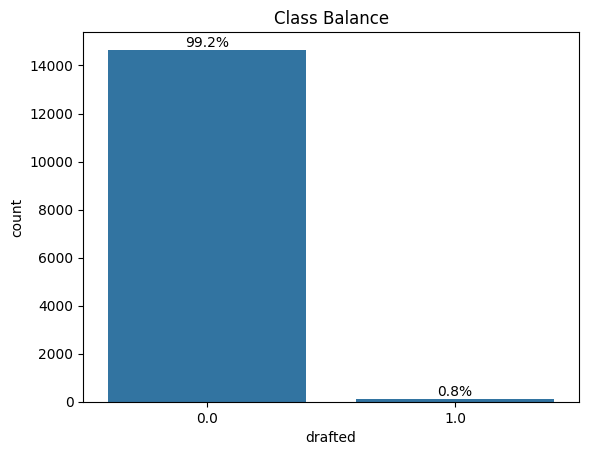

In [177]:
# Analyzing the value distribution of the target in percentage.

def balance_analysis(df, target_name):
    """    Analyzes the balance of the target variable in the DataFrame and visualizes it using a count plot.    """
    total = df[target_name].count()
    ax = sns.countplot(x=target_name, data=df)

    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')

    plt.title("Class Balance")
    plt.show()

balance_analysis(df, target_name)

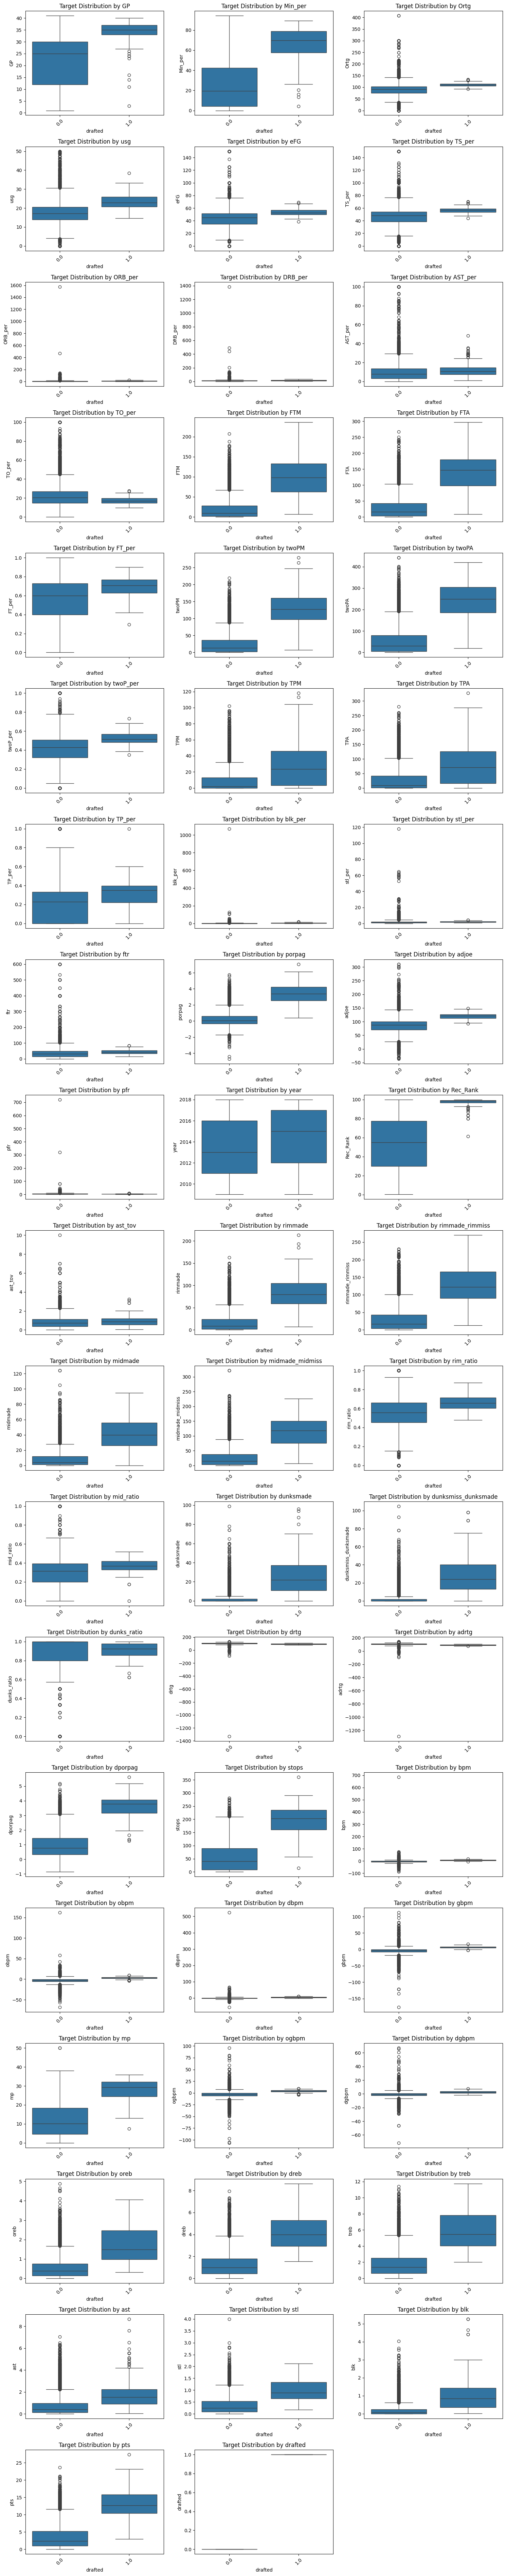

In [178]:
def numerical_analysis(df, target):
    """    Analyzes the numerical features in the dataset and visualizes the distribution of the target variable across them.    """
    dataframe = df.select_dtypes(include=np.number).columns
    num_cols = len(dataframe)
    cols = 3
    rows = math.ceil(num_cols / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(dataframe):
        sns.boxplot(x=df[target], y=df[col], ax=axes[i])
        axes[i].set_title(f"Target Distribution by {col}")
        axes[i].tick_params(axis='x', rotation=45)

    for i in range(num_cols, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

numerical_analysis(df, target_name)

In [179]:
# <Student to fill this section>
target_distribution_explanations = """
In the dataset, there are 14774 registers for the target variable containing values of 0 and 1 only, meaning there is no missing values or inconsistencies for the target variable. The distribution is highly imbalanced with only 0.8% of the data being of drafted players, which indicates the need for appropriate evaluation metrics such as ROC AUC over simple accuracy. Also, the target variable shows good relationships with numerical features such as GP, Min_per and Rec_Rank. More EDA should be done to understand relationship with categorical features, and validate possible outliers.
"""

In [180]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `\<Explore dataset\>`

In [181]:
# Descriptive statistics of the dataset
df.describe(include='all')

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
count,14774,14774,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,14774.000000,...,14769.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14773.000000,14774,14774.000000
unique,355,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12155,NaN
top,Air Force,ACC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e5876a17-fc6c-4b43-8367-f421b26db445,NaN
freq,72,652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
mean,NaN,NaN,21.251726,25.870123,85.771707,17.256674,41.507628,44.566821,5.644010,11.992744,...,-0.757406,0.552453,1.269347,1.821801,0.717322,0.368722,0.206213,3.662676,NaN,0.007987
std,NaN,NaN,10.517642,23.639878,34.164203,6.332899,20.610900,19.622173,15.097867,15.348129,...,3.773361,0.585068,1.125643,1.625416,0.897261,0.375689,0.343153,3.623175,NaN,0.089015
min,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-71.527600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,12.000000,4.200000,75.600000,13.900000,34.800000,38.820000,1.600000,7.500000,...,-2.138620,0.138900,0.428600,0.625000,0.125000,0.083300,0.000000,1.000000,NaN,0.000000
50%,NaN,NaN,25.000000,19.600000,91.300000,17.200000,44.900000,48.285000,4.200000,11.000000,...,-0.598833,0.381000,1.000000,1.400000,0.400000,0.259300,0.083300,2.448300,NaN,0.000000
75%,NaN,NaN,30.000000,42.900000,102.600000,20.600000,51.400000,54.090000,8.000000,15.100000,...,0.878493,0.764700,1.827600,2.551700,0.971400,0.545500,0.250000,5.363600,NaN,0.000000


In [182]:
# Preview of the dataset
pd.concat([df.head(5), df.tail(5)])

,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.342010,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.421040,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.466500,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.459130,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.756940,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0
14769,Virginia,ACC,29,35.0,83.6,15.1,34.4,37.32,6.1,18.6,...,3.019260,0.7586,2.2069,2.9655,0.8276,0.6207,0.2069,2.4138,2678f4e0-cfa4-491a-88cb-2207f78e21f7,0.0
14770,SMU,CUSA,27,20.5,87.9,12.9,45.2,44.78,2.9,7.3,...,-0.557959,0.2222,0.5556,0.7778,0.3704,0.2963,0.0000,1.6296,45a8a388-7cf9-4ceb-a843-3b22875f6016,0.0
14771,Virginia,ACC,28,84.7,105.8,25.5,45.9,53.72,5.4,14.5,...,0.787983,1.6786,4.3571,6.0357,2.7857,1.0000,0.1071,16.5714,20a2285a-acb6-41f4-810b-9f4d92914ef3,0.0
14772,Arkansas Pine Bluff,SWAC,8,2.5,28.4,18.9,0.0,11.94,3.8,0.0,...,-4.730150,0.1000,0.0000,0.1000,0.2000,0.1000,0.0000,0.6000,1d19a682-2364-4874-abdc-0e340443b6c3,0.0
14773,South Carolina,SEC,11,2.7,86.7,13.6,33.3,36.70,3.1,13.8,...,1.035280,0.1667,0.6667,0.8333,0.0000,0.0833,0.0000,0.6667,484f5c19-1ff8-42c5-bddd-3615614c4c1b,0.0


In [183]:
# Features of interest for EDA
features_eda_list = ["GP", "Min_per", "Ortg", "usg", "eFG", "TS_per", "ORB_per", "DRB_per", "AST_per", "TO_per", "FT_per", "twoP_per", "TP_per", "blk_per", "stl_per", "ht", "porpag", "adjoe", "year", "Rec_Rank", "ast_tov", "rim_ratio", "mid_ratio", "dunksmiss_dunksmade", "drtg", "stops", "gbpm", "mp", "treb", "ast", "stl", "blk", "pts", "drafted"]

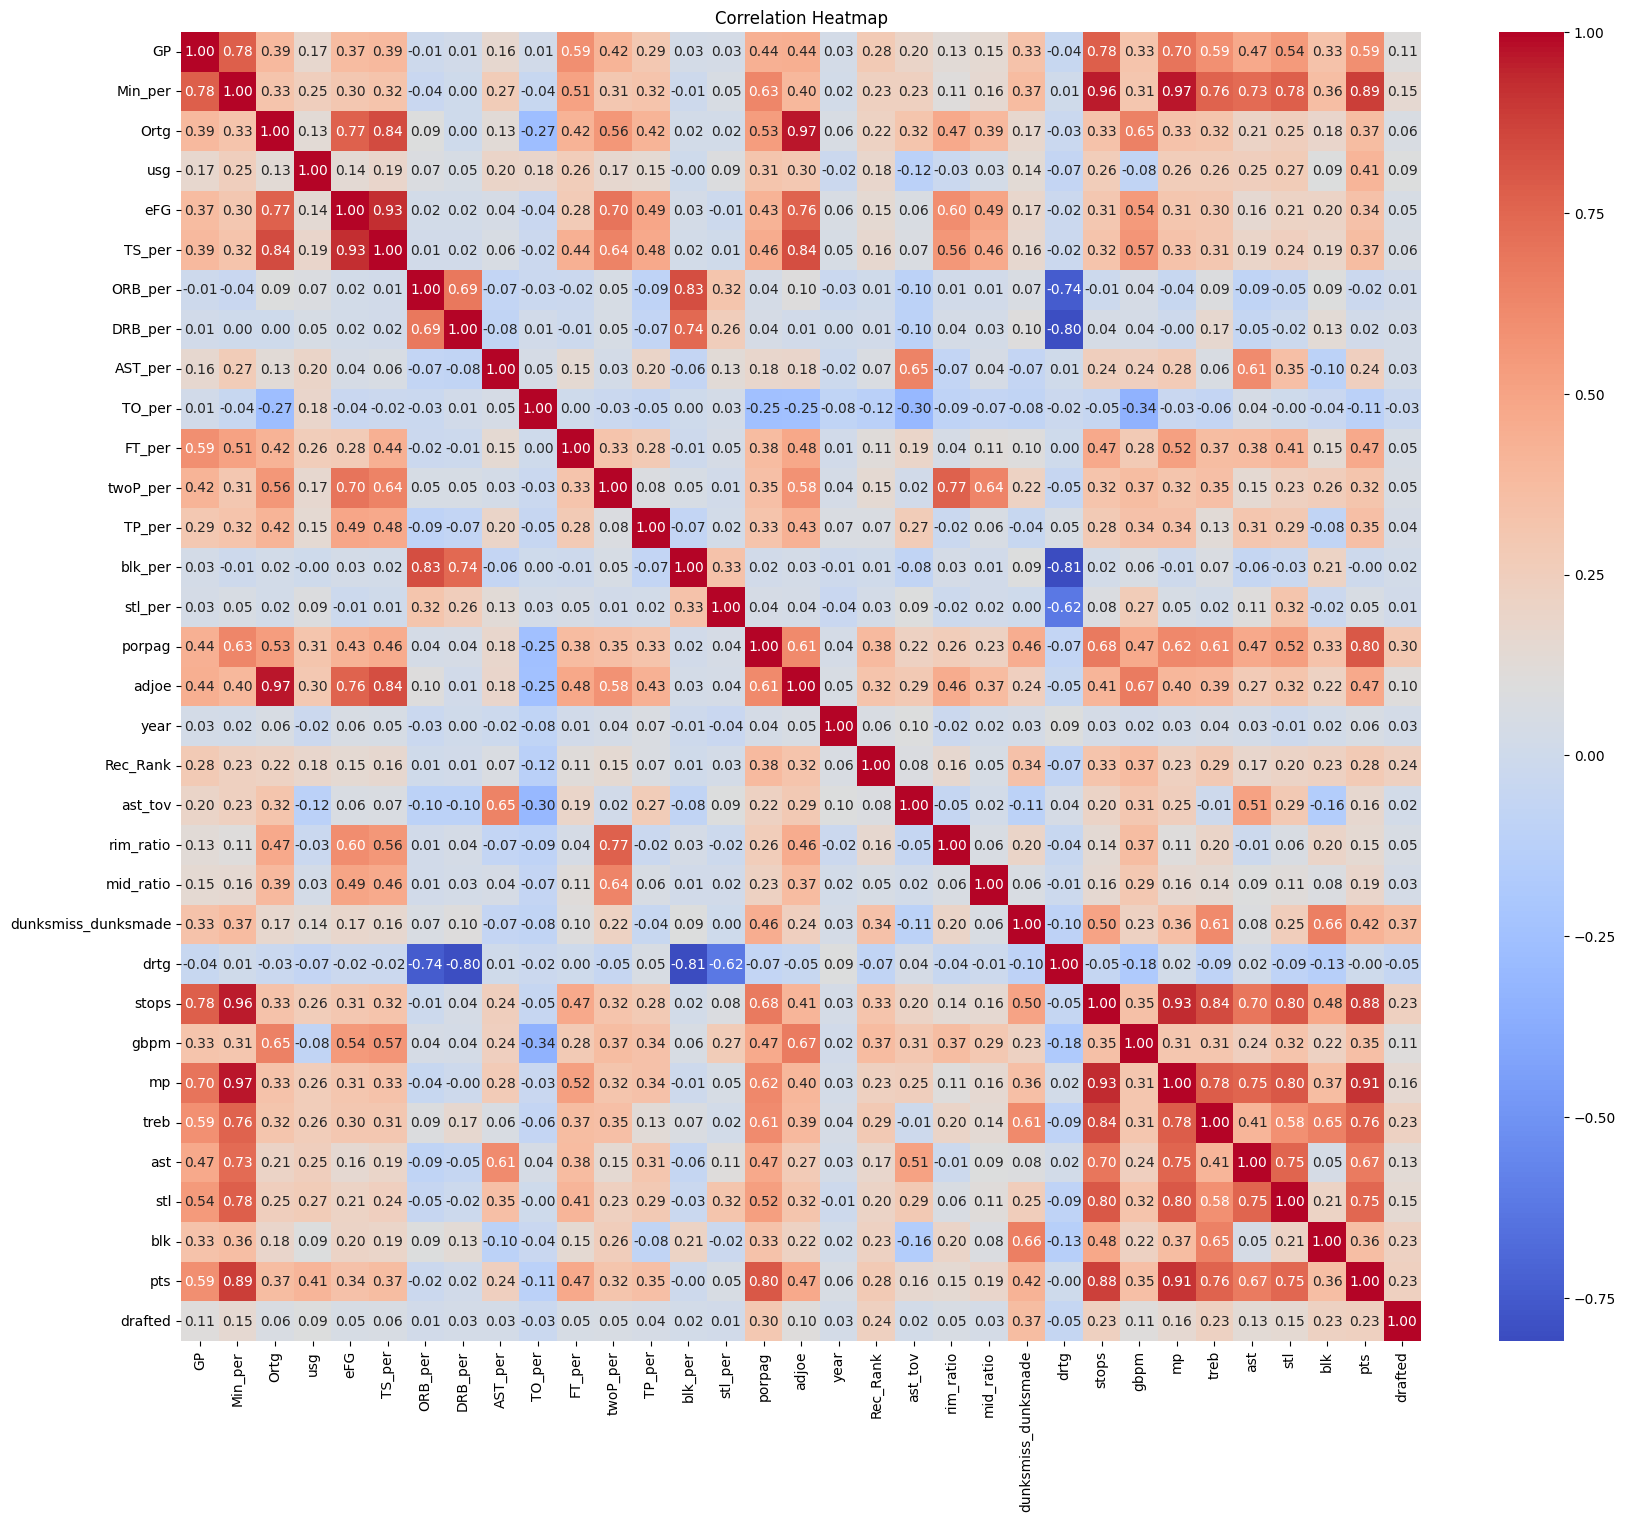

In [184]:
# Exploring correlation heatmap for numerical features of interest

def correlation_heatmap(dataframe, figsize=(5,5)):
    """Plot correlation heatmap for numerical features."""
    plt.figure(figsize=(figsize))
    corr = dataframe[dataframe.select_dtypes(include=np.number).columns.tolist()].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

correlation_heatmap(df[features_eda_list], figsize=(20,17))

In [185]:
# Identifying strong positive/negative correlations

def print_strong_numerical_correlations(dataframe, positive_threshold=0.75, negative_threshold=-0.75):
    """Identify and print strong positive and negative correlations in the DataFrame."""

    corr = dataframe[dataframe.select_dtypes(include=np.number).columns.tolist()].corr()

    positive_threshold = positive_threshold
    negative_threshold = negative_threshold

    strong_positive_correlations = {}
    strong_negative_correlations = {}

    # Iterate correlation matrix getting feature and value
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)): # Avoid duplicates and self-correlation
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            correlation_value = corr.loc[col1, col2]

            # Store strong correlations based on thresholds
            if correlation_value > positive_threshold:
                strong_positive_correlations[f"Features {col1}-{col2}"] = round(float(correlation_value), 2)
            elif correlation_value < negative_threshold:
                strong_negative_correlations[f"Features {col1}-{col2}"] = round(float(correlation_value), 2)

    # Display strong correlations
    print(f"Strong Positive Correlations (higher than {positive_threshold}):\n")
    for item in strong_positive_correlations.items():
        print(item)

    print(f"\nStrong Negative Correlations (lower than {negative_threshold}):\n")
    for item in strong_negative_correlations.items():
        print(item)

print_strong_numerical_correlations(df[features_eda_list])

Strong Positive Correlations (higher than 0.75):

('Features GP-Min_per', 0.78)
('Features GP-stops', 0.78)
('Features Min_per-stops', 0.96)
('Features Min_per-mp', 0.97)
('Features Min_per-treb', 0.76)
('Features Min_per-stl', 0.78)
('Features Min_per-pts', 0.89)
('Features Ortg-eFG', 0.77)
('Features Ortg-TS_per', 0.84)
('Features Ortg-adjoe', 0.97)
('Features eFG-TS_per', 0.93)
('Features eFG-adjoe', 0.76)
('Features TS_per-adjoe', 0.84)
('Features ORB_per-blk_per', 0.83)
('Features twoP_per-rim_ratio', 0.77)
('Features porpag-pts', 0.8)
('Features stops-mp', 0.93)
('Features stops-treb', 0.84)
('Features stops-stl', 0.8)
('Features stops-pts', 0.88)
('Features mp-treb', 0.78)
('Features mp-ast', 0.75)
('Features mp-stl', 0.8)
('Features mp-pts', 0.91)
('Features treb-pts', 0.76)
('Features ast-stl', 0.75)

Strong Negative Correlations (lower than -0.75):

('Features DRB_per-drtg', -0.8)
('Features blk_per-drtg', -0.81)


In [186]:
# Checking for missing values in the dataset

def check_missing_values(dataframe):
    """Check for missing values in the DataFrame and print the count and percentage of missing values for each column."""
    
    # Aux variables
    summary = {}
    total_rows = len(dataframe)

    # Check each column for missing values
    for col in dataframe.columns:
        missing_count = dataframe[col].isnull().sum()
        if missing_count > 0:
            missing_percentage = (missing_count / total_rows) * 100
            summary[col] = {
                'missing_count': missing_count,
                'missing_percentage': round(missing_percentage, 2)
            }

    if not summary:
        print("No missing values found in the DataFrame.")
    else:
        print("Missing Values Summary:")
        for col, info in summary.items():
            print(f"Column: {col}, Missing Count: {info['missing_count']}, Missing Percentage: {info['missing_percentage']}%")

check_missing_values(df[features_eda_list])

Missing Values Summary:
Column: ht, Missing Count: 8, Missing Percentage: 0.05%
Column: Rec_Rank, Missing Count: 9885, Missing Percentage: 66.91%
Column: ast_tov, Missing Count: 1535, Missing Percentage: 10.39%
Column: rim_ratio, Missing Count: 3203, Missing Percentage: 21.68%
Column: mid_ratio, Missing Count: 3191, Missing Percentage: 21.6%
Column: dunksmiss_dunksmade, Missing Count: 2075, Missing Percentage: 14.04%
Column: drtg, Missing Count: 5, Missing Percentage: 0.03%
Column: stops, Missing Count: 5, Missing Percentage: 0.03%
Column: gbpm, Missing Count: 5, Missing Percentage: 0.03%
Column: mp, Missing Count: 1, Missing Percentage: 0.01%
Column: treb, Missing Count: 1, Missing Percentage: 0.01%
Column: ast, Missing Count: 1, Missing Percentage: 0.01%
Column: stl, Missing Count: 1, Missing Percentage: 0.01%
Column: blk, Missing Count: 1, Missing Percentage: 0.01%
Column: pts, Missing Count: 1, Missing Percentage: 0.01%


In [187]:
# Checking for duplicated rows in the dataset

def check_duplicated_rows(dataframe):
    """Check for duplicated rows in the DataFrame and print the count of duplicated rows."""
    duplicated_count = dataframe.duplicated().sum()
    if duplicated_count == 0:
        print("No duplicated rows found in the DataFrame.")
    else:
        print(f"Duplicated Rows Summary:\nTotal Duplicated Rows: {duplicated_count}\n")
        print(f"First 3 duplicated rows:\n")
        print(dataframe[dataframe.duplicated()].head(3))  # Display first 3 duplicated rows as sample

check_duplicated_rows(df)

Duplicated Rows Summary:
Total Duplicated Rows: 2462

First 3 duplicated rows:

             team  conf  GP  Min_per   Ortg   usg   eFG  TS_per  ORB_per  \
12312     Liberty  BSth  14      1.5   54.6  34.8  18.8   27.93     14.2   
12313  Cincinnati    BE  31     53.7  103.7  19.5  45.0   48.54      6.6   
12314    Ball St.   MAC  23     26.3   72.5  16.8  25.0   34.57      4.6   

       DRB_per  ...     dgbpm    oreb    dreb    treb     ast     stl     blk  \
12312     26.8  ... -1.070620  0.1111  0.2778  0.3889  0.0556  0.1667  0.0000   
12313      9.9  ... -0.384077  1.2903  1.8710  3.1613  1.3871  0.4516  0.1613   
12314      8.7  ... -0.579843  0.5652  1.0435  1.6087  1.0000  0.2609  0.1304   

          pts                             player_id  drafted  
12312  0.2778  bace233f-cb91-4518-876f-66099be5ad37      0.0  
12313  7.2903  e9370cf9-f64f-4666-b905-b041e2ca111c      0.0  
12314  2.2609  07b7b849-1636-40ba-8418-9998c66a9d4c      0.0  

[3 rows x 62 columns]


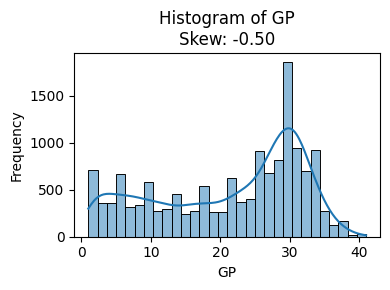

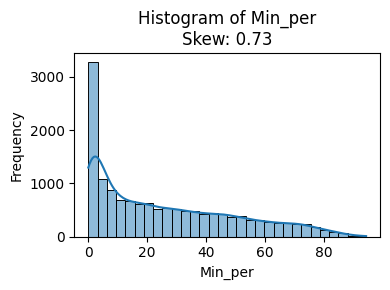

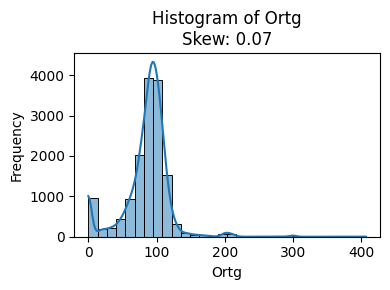

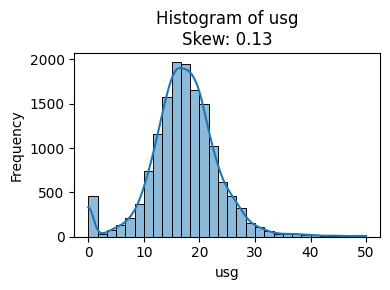

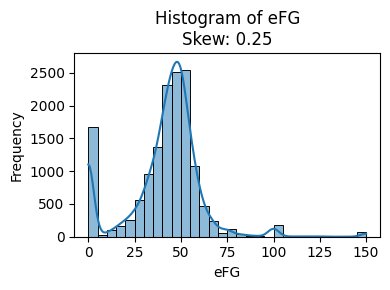

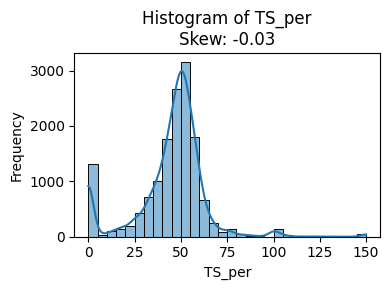

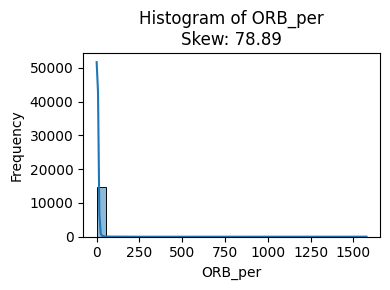

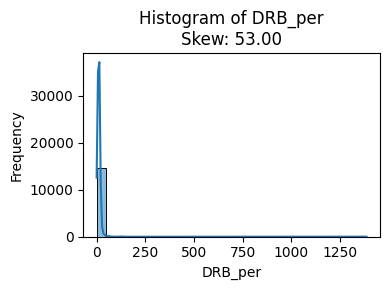

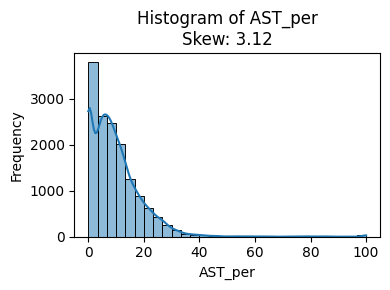

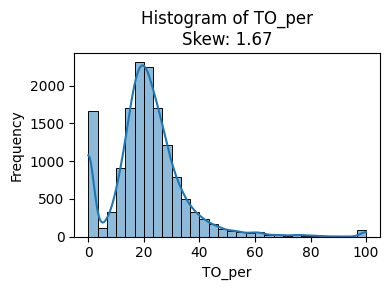

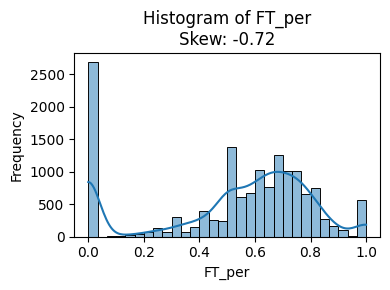

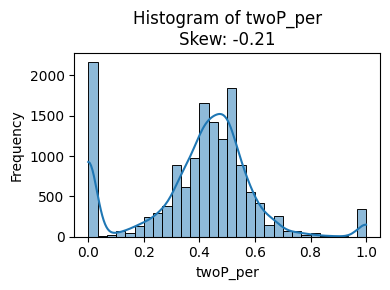

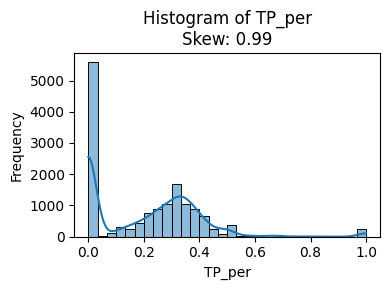

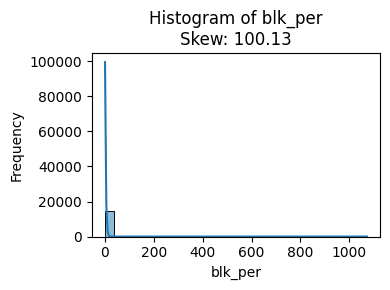

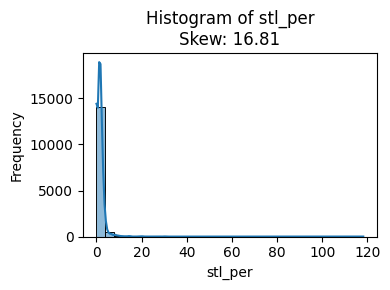

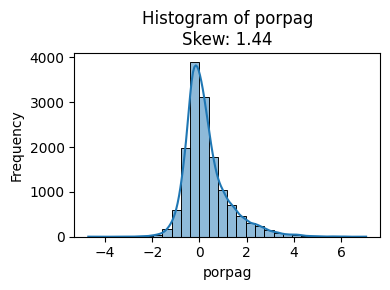

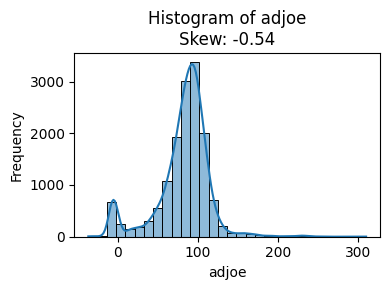

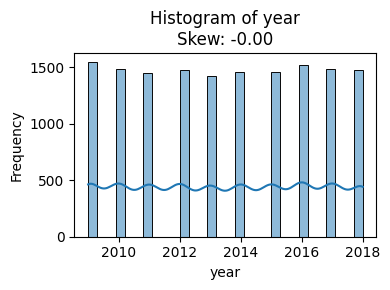

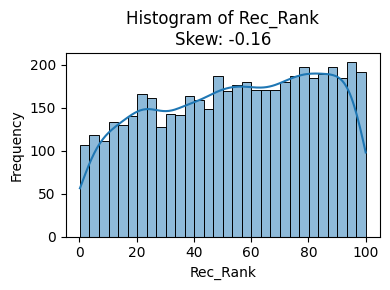

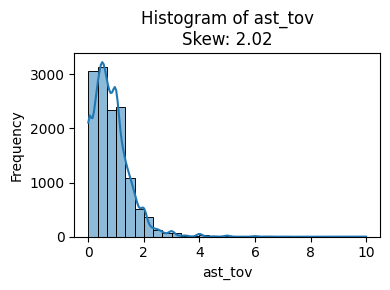

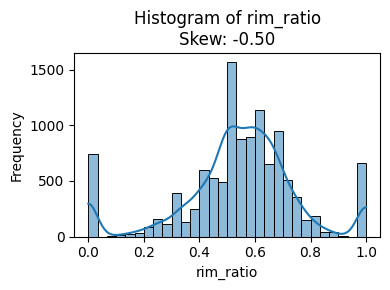

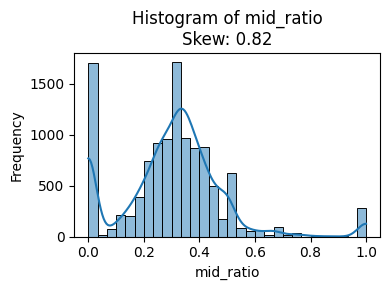

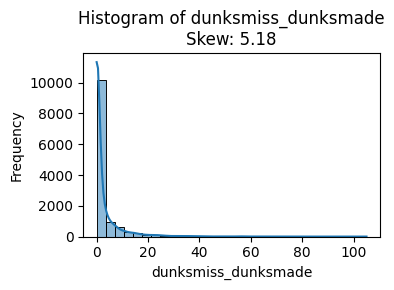

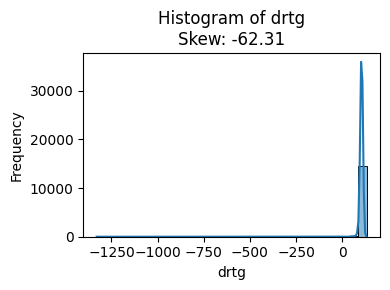

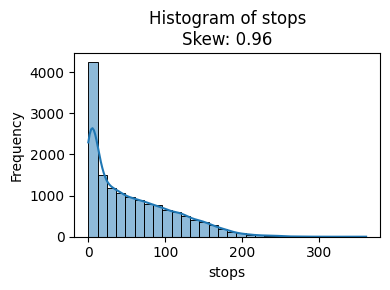

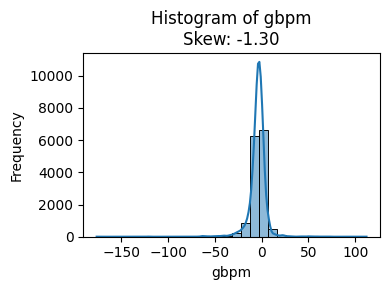

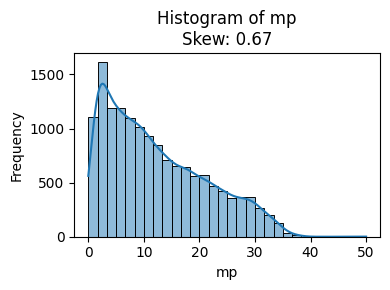

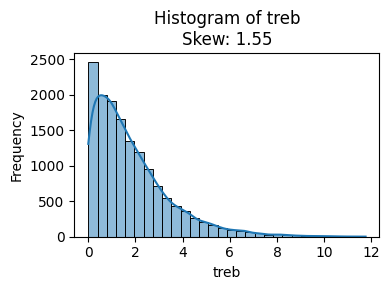

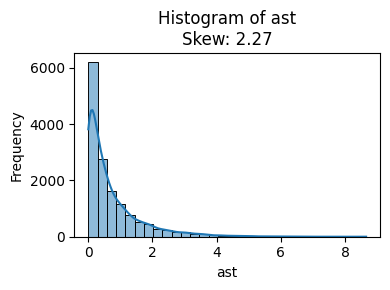

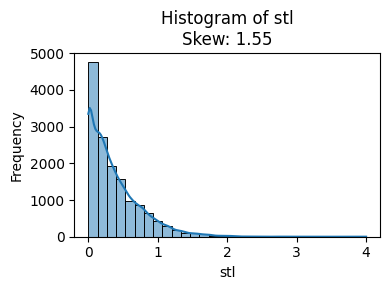

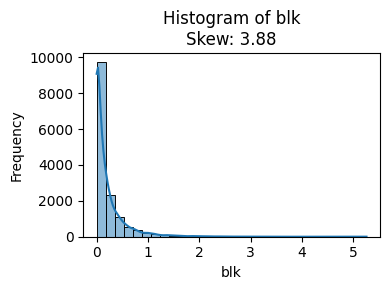

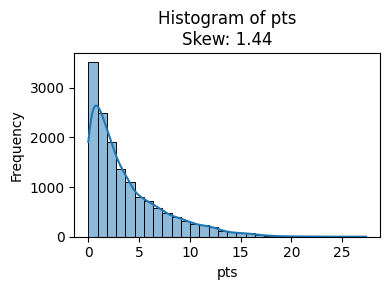

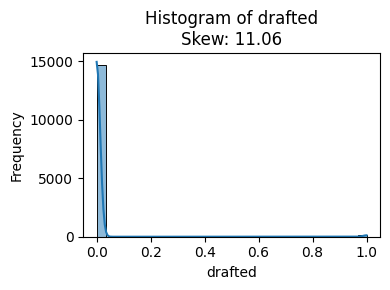

In [188]:
# Checking skewness for numerical features

def check_numerical_skewness(dataframe):
    """Plot skewness for numerical features in the DataFrame."""

    for col in dataframe.select_dtypes(include=np.number).columns:
        plt.figure(figsize=(4, 3))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'Histogram of {col}\nSkew: {dataframe[col].skew():.2f}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

check_numerical_skewness(df[features_eda_list])

In [189]:
# <Student to fill this section>
feature_1_insights = """
Through descriptive analysis on the dataset, problems like inconsistency, incorrect format and outliers were found (e.g. columns adrtg, ht and USG). Also, the big difference of values in the features may suggest the need for feature scaling later on. From correlation matrix was possible to identify possible redundant or leakage features (e.g. Min_per against MP with 0.97 points of correlation, and porpag against pts); Some features (e.g. pts, stops and stl) are highly positive correlated with minutes played features, since the time of a player on the game influence directly on the quantity of times those actions are made. The dataset contains many missing values with some features reaching up to 66.91% of missing values in the whole dataset. 2462 duplicated rows were found, and many features showed skewness problems (e.g. ast, stl, pts). Further analysis on specific features must be made to understand issues in details, and problems found in this EDA may or may not be fixed in this experiment depending on the need for so.
"""

In [190]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `\<ht\>`

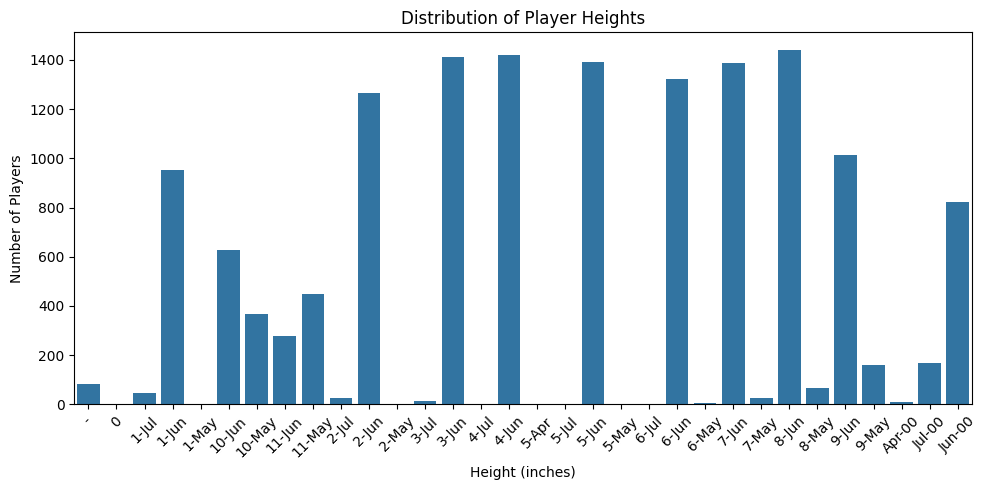

In [191]:
# Understanding feature height format

ht_values = df['ht'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=ht_values.index, y=ht_values.values)
plt.title('Distribution of Player Heights')
plt.xlabel('Height (inches)')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [192]:
# <Student to fill this section>
feature_2_insights = """
Height (ht) is a critical attribute in basketball, often influencing a player's position and role on the team. The dataset shows a wide range of heights, with values appearing as date instead of height measurement system, which shows inconsistency and incorrect format. This suggests potential data entry errors and the need for standardisation of height measurements. Addressing these issues is essential for accurate analysis and modelling, as height can significantly impact performance metrics and draft likelihood.
"""

In [193]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `\<year\>`


In [194]:
# Raw count distribution of non drafted and drafted by year
ct = pd.crosstab(df['year'], df['drafted'])
ct

drafted,0.0,1.0
year,,
2009,1543,5
2010,1470,12
2011,1446,6
2012,1466,10
2013,1412,10
2014,1448,12
2015,1440,16
2016,1508,14
2017,1469,15


In [195]:
# <Student to fill this section>
feature_3_insights = """
Year could possibly be a feature for data splitting since it maintains a healthy historical behaviour simulation. No issues were found in the feature year.
"""

In [196]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest `\<Multiple Featues\>`

> You can add more cells related to other feeatures in this section

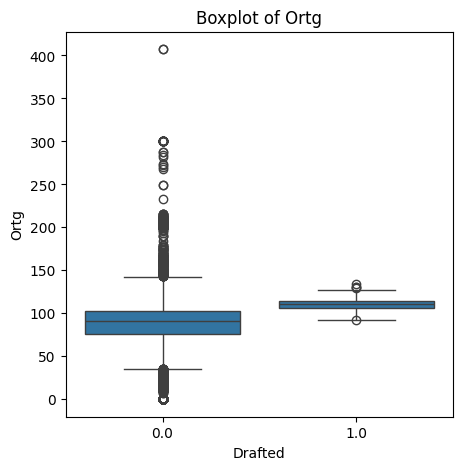

In [197]:
# Exploring Feature of Interest `\<Ortg\>`

plt.figure(figsize=(5, 5))
sns.boxplot(x=df[target_name], y=df['Ortg'])
plt.title('Boxplot of Ortg')
plt.xlabel('Drafted')
plt.ylabel('Ortg')
plt.show()

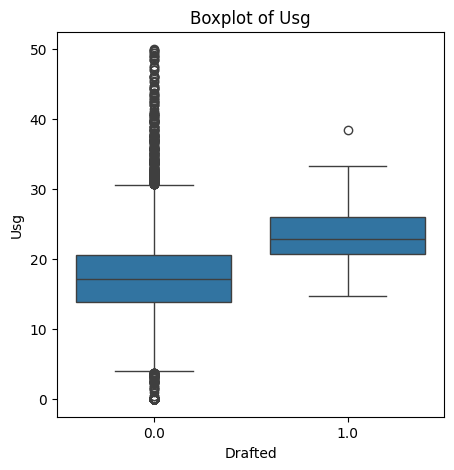

In [198]:
# Exploring Feature of Interest `\<Usg\>`

plt.figure(figsize=(5, 5))
sns.boxplot(x=df[target_name], y=df['usg'])
plt.title('Boxplot of Usg')
plt.xlabel('Drafted')
plt.ylabel('Usg')
plt.show()

In [199]:
# <Student to fill this section>
feature_4_insights = """
Features Ortg and Usg show high outliers that are possibly not realistic based on statistics shown in NBA basketabll references website. These outliers may need to be addressed by capping or transformation to ensure they do not negatively influence the model training process. Other features such as eFG, TS_per and ORB_per presents the same behaviour as previously shown in the target exploration step.
"""

In [200]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest `\<Multiple Featues 2\>`

In [201]:
# Exploring Feature of Interest `\<Pts\>`
df['pts'].value_counts().sort_index()

pts
0.0000     1182
0.0556        1
0.0625        2
0.0667        2
0.0714        5
           ... 
21.0303       1
21.1000       1
23.1600       1
23.6970       1
27.3750       1
Name: count, Length: 3453, dtype: int64

In [202]:
# Exploring Feature of Interest `\<blk\>`
df['blk'].value_counts().sort_index()

blk
0.0000    5009
0.0256       1
0.0263       3
0.0270       3
0.0278      16
          ... 
3.6333       1
4.0303       1
4.4167       2
4.6500       1
5.2581       2
Name: count, Length: 694, dtype: int64

In [203]:
# <Student to fill this section>
feature_5_insights = """
Features pts and blk seams to show incorrect format for values, with both features having decimal values when they should be integers. Correcting these inconsistencies is crucial for reliable performance metrics and draft likelihood predictions. Other features such as stl, ast and treb present the same behaviour.
"""

In [204]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

---
## D. Feature Selection


### D.1 Approach "\<Point_biserial\>"


In [205]:
# Transforming feature height in a new column for feature selection approach
def height_data_cleaning(value):

    month_map = {'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7}
    value = str(value)  # Ensure it's a string
    
    try:
        if value.startswith('-'):  # 
            return 0
        elif value.isdigit():  # If ht is a single number, use it
            return int(value)
        elif value[0].isdigit(): # If ht starts with a digit, e.g., "1-May"
            inches, feet = value.split('-')
            feet = month_map[feet]
            total_inches = int(feet) * 12 + int(inches)
            return total_inches
        elif value[0].isalpha():  # If ht starts with a letter, e.g., "Jun-00"
            feet, inches = value.split('-')
            feet = month_map[feet]
            total_inches = int(feet) * 12 + int(inches)
            return total_inches
        else:
            return 0  # Assign None for other unknown values
    except Exception as e:
        return 0

# Apply function to create new column
df["ht"] = df["ht"].apply(height_data_cleaning)
X_test["ht"] = X_test["ht"].apply(height_data_cleaning)

In [206]:
# Point-biserial correlation between numerical features and the binary target variable
def point_biserial_correlation(dataframe, target):
    """Calculate point-biserial correlation between numerical features and a binary target variable."""
    corr_results = []
    for col in dataframe.select_dtypes(include=np.number).columns:
        corr, p = pointbiserialr(dataframe[target], dataframe[col], nan_policy='omit')
        corr_results.append({'feature': col, 'correlation': corr, 'p_value': p})

    corr_df = pd.DataFrame(corr_results)
    top_corr = corr_df.sort_values(by='p_value').reset_index(drop=True)
    top_corr = top_corr[top_corr['p_value'] < 0.05]
    return corr_df, top_corr

correlation, top_correlation = point_biserial_correlation(df, target_name)

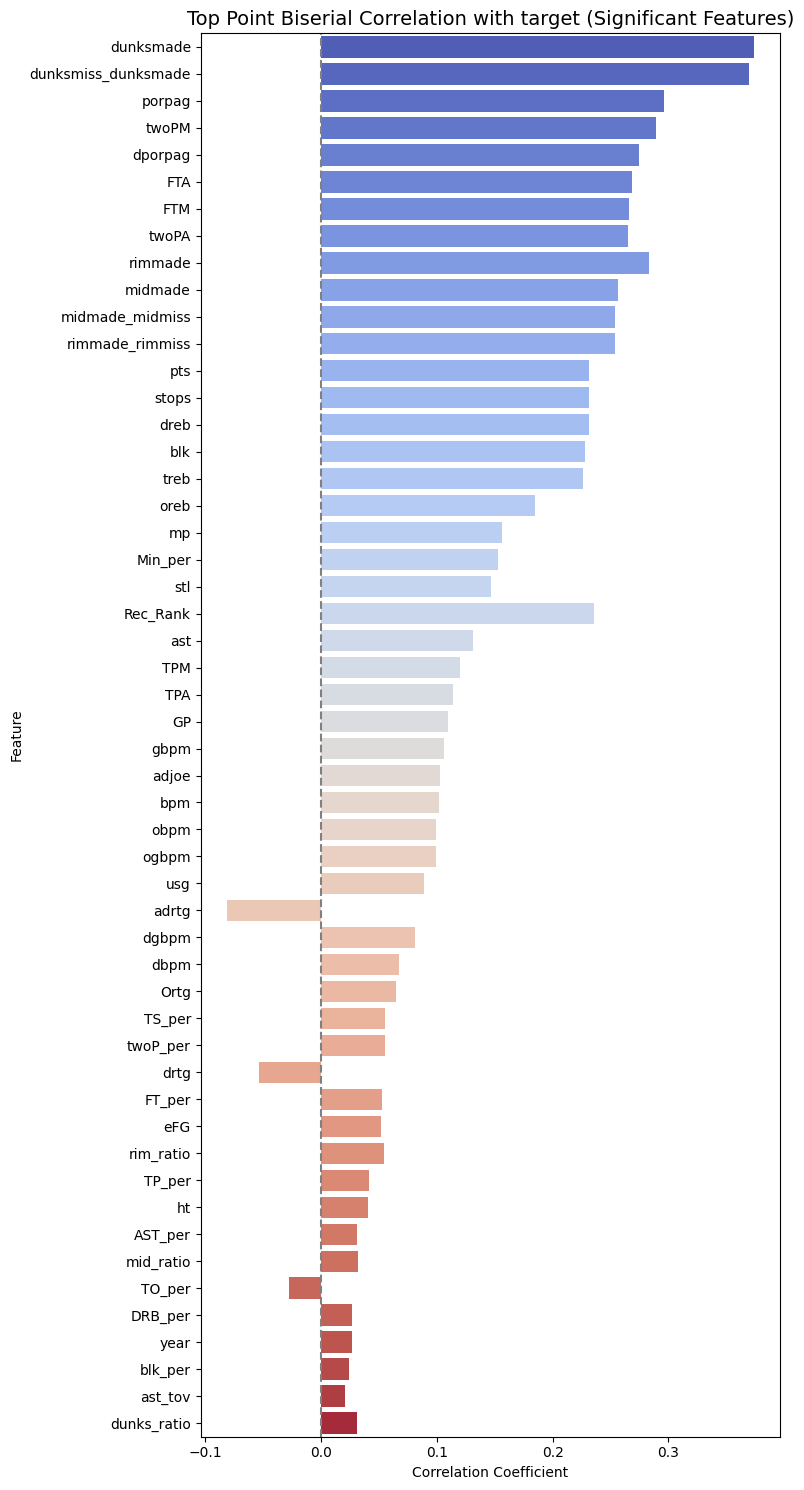

In [207]:
# Plot top significant correlations
top_corr_df = top_correlation[top_correlation['feature'] != target_name]

plt.figure(figsize=(8, 15))
sns.barplot(data=top_corr_df, x='correlation', y='feature', palette='coolwarm')
plt.title('Top Point Biserial Correlation with target (Significant Features)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [208]:
# <Student to fill this section>
feature_selection_1_insights = """
Point-biserial correlation analysis was used as approach for feature selection on this experiment. The approach is helpful due to its statistical measurement to quantify the relationship between a binary variable (target) and a continuous variable (features), giving insights about coefficient correlation and its associated p-value. The results show several features with significant correlations to the target variable 'drafted'. Notably, features such as 'dunksmade', 'dunkmiss_dunksmade', 'porpag' and 'twoPM' exhibited strong positive correlations, suggesting that players with higher points made overall are more likely to be drafted. On the other hand, features like 'adrtg' and 'TO_per' showed negative correlations, indicating that lower defensive ratings may decrease draft likelihood. These insights will guide feature selection for model development for next experiments.
"""

In [209]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "\<describe_approach_here\>"


In [210]:
# <Student to fill this section>

In [211]:
# <Student to fill this section>
feature_selection_2_insights = """
provide an explanation on why you use this approach for feature selection and describe its results
"""

In [212]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.n Approach "\<describe_approach_here\>"

> You can add more cells related to other approaches in this section

## D.z Final Selection of Features

In [213]:
# <Student to fill this section>

features_list = ["gp", "ortg", "usg", "efg", "ts_per", "to_per", "twopm", "tpm", "ht", "porpag", "adjoe", "rec_rank", "dunksmiss_dunksmade", "adrtg", "fta", "stops", "gbpm", "mp", "dreb", "ast", "stl", "blk", "pts"]

In [214]:
# <Student to fill this section>
feature_selection_explanations = """
The selected features are based on the point-biserial correlation analysis results, focusing on those with significant correlations to the target variable 'drafted'. This selection aims to balance offensive and defensive attributes, providing a comprehensive view of player performance. Future experiments will also be used as way to validate selected features.
"""

In [215]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <Duplication__Missing_Values__Format>

In [216]:
# Removing duplicated rows
df_cleaned = df.drop_duplicates().reset_index(drop=True)

In [217]:
# Transforming columns names to lowercase for easier handling
df_cleaned.columns = df_cleaned.columns.str.lower()
X_test.columns = X_test.columns.str.lower()

In [218]:
# Removing unnecessary columns
df_cleaned = df_cleaned.drop(columns=['team', 'conf', 'yr', 'type', 'player_id'])

In [219]:
# Transforming value format in features with decimals that should be integers
int_columns = ['pts', 'blk', 'stl', 'ast', 'treb', 'dreb', 'oreb']
for col in int_columns:
    df_cleaned[col] = df_cleaned[col].apply(lambda x: int(x*100) if pd.notnull(x) else x)
    X_test[col] = X_test[col].apply(lambda x: int(x*100) if pd.notnull(x) else x)

In [220]:
# Atributing mode value to missing values in numerical features with small number of missing values
small_miss_columns = ['pts', 'blk', 'stl', 'ast', 'treb', 'dreb', 'oreb', 'dgbpm', 'ogbpm', 'mp', 'gbpm', 'dbpm', 'obpm', 'bpm', 'stops', 'dporpag', 'adrtg', 'drtg']

for col in small_miss_columns:
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
    X_test[col].fillna(X_test[col].mode()[0], inplace=True)


In [221]:
# Atributing median value to missing values in numerical features based on columns "efg" and "ts_per"
shot_col_miss_val = ['rimmade', 'rimmade_rimmiss', 'midmade', 'midmade_midmiss', 'dunksmade', 'dunksmiss_dunksmade']
for col in shot_col_miss_val:
    try:
        # Group values by efg and ts_per (without decimals), then fill missing values with the median of the group
        df_cleaned[col].fillna(df_cleaned.groupby([df_cleaned['efg'].round(), df_cleaned['ts_per'].round()])[col].transform(lambda x: x.max() - x.min()), inplace=True)
        X_test[col].fillna(X_test.groupby([X_test['efg'].round(), X_test['ts_per'].round()])[col].transform(lambda x: x.max() - x.min()), inplace=True)
    except Exception as e:
        pass


In [222]:
# Atributing mode value to missing values that were not filled by previous step
for col in shot_col_miss_val:
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
    X_test[col].fillna(X_test[col].mode()[0], inplace=True)
    

In [223]:
# Handling missing values to ratio features based on the calculation of made/miss shots
ratio_col_miss_val = ['rim_ratio', 'mid_ratio', 'dunks_ratio']
for col in ratio_col_miss_val:
    if col == 'rim_ratio':
        df_cleaned[col] = np.where(df_cleaned['rimmade'] != 0, df_cleaned['rimmade'] / df_cleaned['rimmade_rimmiss'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['rimmade'] != 0, X_test['rimmade'] / X_test['rimmade_rimmiss'], 0).round(2)
    elif col == 'mid_ratio':
        df_cleaned[col] = np.where(df_cleaned['midmade'] != 0, df_cleaned['midmade'] / df_cleaned['midmade_midmiss'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['midmade'] != 0, X_test['midmade'] / X_test['midmade_midmiss'], 0).round(2)
    elif col == 'dunks_ratio':
        df_cleaned[col] = np.where(df_cleaned['dunksmade'] != 0, df_cleaned['dunksmade'] / df_cleaned['dunksmiss_dunksmade'], 0).round(2) # Handles division by zero
        X_test[col] = np.where(X_test['dunksmade'] != 0, X_test['dunksmade'] / X_test['dunksmiss_dunksmade'], 0).round(2)

# Atributing 1 to "inf" values and value higher than 1 in ratio features due to division by zero and unrealistic values from inputs
for col in ratio_col_miss_val:
    df_cleaned[col].replace([np.inf, -np.inf], 1, inplace=True)
    X_test[col].replace([np.inf, -np.inf], 1, inplace=True)
    df_cleaned[col] = np.where(df_cleaned[col] > 1, 1, df_cleaned[col]) # Cap values higher than 1 to 1
    X_test[col] = np.where(X_test[col] > 1, 1, X_test[col]) # Cap values higher than 1 to 1

In [224]:
# Atributing mean value to missing values in ast_tov feature based on columns "ast_per" and "to_per"
try:
    # Group values by ast_per and to_per (without decimals), then fill missing values with mean of the group
    df_cleaned['ast_tov'].fillna(df_cleaned.groupby([df_cleaned['ast_per'].round(), df_cleaned['to_per'].round()])['ast_tov'].transform('mean'), inplace=True)
    X_test['ast_tov'].fillna(X_test.groupby([X_test['ast_per'].round(), X_test['to_per'].round()])['ast_tov'].transform('mean'), inplace=True)
except Exception as e:
    pass

In [225]:
# Atributing mean value to ast_tov missing values that were not filled by previous step
df_cleaned['ast_tov'].fillna(df_cleaned['ast_tov'].mean(), inplace=True)
X_test['ast_tov'].fillna(X_test['ast_tov'].mean(), inplace=True)

In [226]:
# <Student to fill this section>
data_cleaning_1_explanations = """
In this step duplication, missing values and incorrect format was fixed. Duplication was specially important to fix due to redundancy of data, and models will learn same pattern if it stays in the dataset. The missing values were fixed using rules of calculations to simulate real values as much as possible, and features with incorrect format were fix for a better interpretability and standardisation. The feature rec_rank was left of fix for missing values due to lack of business knowledge of how to compute values, and decided to drop the feature due to high volume of missing values.
"""

In [227]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <Max_Min_Values>

In [228]:
# Transforming outliers in numerical features by capping values based on NBA basketball website references (e.g. https://www.statmuse.com/ask/highest-ortg?l=nba)

for df in [df_cleaned, X_test]:
    df['ortg'] = np.where(df['ortg'] > 130, df['ortg'].mean().round(2), df['ortg']) # Capping Ortg to 130
    df['usg'] = np.where(df['usg'] > 35, df['usg'].mean().round(2), df['usg']) # Capping usg to 35
    df['efg'] = np.where(df['efg'] > 50, df['efg'].mean().round(2), df['efg']) # Capping efg to 50
    df['ts_per'] = np.where(df['ts_per'] > 100, df['ts_per'].mean().round(2), df['ts_per']) # Capping ts_per to 100
    df['orb_per'] = np.where(df['orb_per'] > 100, df['orb_per'].mean().round(2), df['orb_per']) # Capping orb_per to 100
    df['drb_per'] = np.where(df['drb_per'] > 100, df['drb_per'].mean().round(2), df['drb_per']) # Capping drb_per to 100
    df['blk_per'] = np.where(df['blk_per'] > 100, df['blk_per'].mean().round(2), df['blk_per']) # Capping blk_per to 100
    df['stl_per'] = np.where(df['stl_per'] > 100, df['stl_per'].mean().round(2), df['stl_per']) # Capping stl_per to 100
    df['ftr'] = np.where(df['ftr'] > 100, df['ftr'].mean().round(2), df['ftr']) # Capping ftr to 100
    df['pfr'] = np.where(df['pfr'] > 100, df['pfr'].mean().round(2), df['pfr']) # Capping pfr to 100
    df['bpm'] = np.where(df['bpm'] > 100, df['bpm'].mean().round(2), df['bpm']) # Capping bpm to 100
    df['obpm'] = np.where(df['obpm'] > 100, df['obpm'].mean().round(2), df['obpm']) # Capping obpm to 100
    df['dbpm'] = np.where(df['dbpm'] > 100, df['dbpm'].mean().round(2), df['dbpm']) # Capping dbpm to 100

In [229]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Features with outliers were capped based on references from NBA basketball statistics website. Features that did not have any reference or business knowledge was left without treatment for outliers. The treatment is specially helpful to avoid models being influenced by extreme values that do not represent real world scenarios, and helps to improve model generalization and performance.
"""

In [230]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

In [231]:
# <Student to fill this section>

In [232]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Provide some explanations on why you believe it is important to fix this issue and its impacts
"""

In [233]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.n Fixing "\<describe_issue_here\>"

> You can add more cells related to other issues in this section

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"


In [234]:
# <Student to fill this section>

In [235]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [236]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"




In [237]:
# <Student to fill this section>

In [238]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [239]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [240]:
# <Student to fill this section>

In [241]:
# <Student to fill this section>
feature_engineering_n_explanations = """
Provide some explanations on why you believe it is important to create this feature and its impacts
"""

In [242]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.n Fixing "\<describe_issue_here\>"

> You can add more cells related to new features in this section

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [243]:
df_cleaned

,gp,min_per,ortg,usg,efg,ts_per,orb_per,drb_per,ast_per,to_per,...,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,drafted
0,26,52.6,111.8,19.3,41.52,64.93,1.1,7.5,17.6,24.7,...,2.85299,-1.34201,23.0,157.0,180.0,223.0,65.0,7.0,965.0,0.0
1,2,0.8,63.6,29.6,33.30,33.33,0.0,21.5,0.0,19.6,...,-7.10210,-5.42104,0.0,100.0,100.0,0.0,0.0,0.0,200.0,0.0
2,4,0.6,61.4,21.7,50.00,50.00,0.0,0.0,0.0,40.3,...,-7.07681,6.46650,0.0,0.0,0.0,0.0,25.0,0.0,50.0,0.0
3,28,59.2,88.2,21.7,46.20,47.25,1.5,9.7,25.2,27.4,...,-1.59327,1.45913,32.0,203.0,235.0,300.0,128.0,7.0,775.0,0.0
4,21,13.7,47.5,15.0,26.20,26.20,5.8,2.3,10.2,47.1,...,-10.30560,-3.75694,38.0,14.0,52.0,42.0,19.0,0.0,57.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,2,0.3,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,-4.93014,-3.31945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12308,1,0.2,54.9,25.6,0.00,0.00,0.0,0.0,76.7,0.0,...,-4.35779,-8.03099,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0
12309,3,0.4,0.0,9.0,0.00,0.00,0.0,0.0,0.0,0.0,...,-4.95202,6.09315,0.0,0.0,0.0,0.0,33.0,0.0,0.0,0.0
12310,3,0.2,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,-21.72670,-2.06139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [244]:
# Transforming year to date type
df_eng = df_cleaned.copy()
df_eng['year'] = pd.to_datetime(df_eng['year'], format='%Y')
df_eng['year'].dt.year.inplace=True

# Sort dataframe in ascending order
df_eng.sort_values(by='year', inplace=True)

In [245]:
# Extract target variable (y) and features (x)
y = df_eng.pop(target_name)
X = df_eng

In [246]:
# Splitting data set.

# Create a variable called one_fifth that will contain the number of rows that corresponds to 20% of the dataframe. Round it to the closest integer.
one_fifth = round(len(X) / 5)

#  Create X_train and y_train that will contain the first 60% of the original dataframe
X_train = X[: one_fifth * 3]
y_train = y[: one_fifth * 3]

# Create X_val, y_val that will respectively contain remaining 40% of the original dataframe
X_val = X[one_fifth * 3:]
y_val = y[one_fifth * 3:]

In [247]:
# Dropping year from datasets
X_train.drop(['year'], axis=1, inplace=True)
X_val.drop(['year'], axis=1, inplace=True)


In [248]:
# <Student to fill this section>
data_splitting_explanations = """
Splitting the dataset by year simulates predicting future, enabling temporal validation.
"""

In [249]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

In [250]:
# <Student to fill this section>
data_transformation_1_explanations = """
No transformations needed.
"""

In [251]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

In [252]:
# <Student to fill this section>

In [253]:
# <Student to fill this section>
data_transformation_2_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [254]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

In [255]:
# <Student to fill this section>

In [256]:
# <Student to fill this section>
data_transformation_3_explanations = """
Provide some explanations on why you believe it is important to perform this data transformation and its impacts
"""

In [257]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [258]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv('../data/processed/X_train.csv', index=False)
  y_train.to_csv('../data/processed/y_train.csv', index=False)

  X_val.to_csv('../data/processed/X_val.csv', index=False)
  y_val.to_csv('../data/processed/y_val.csv', index=False)

  X_test.to_csv('../data/processed/X_test.csv', index=False)

except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [259]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve


In [260]:
# <Student to fill this section>
performance_metrics_explanations = """
Due to the imbalanced nature of the target variable, ROC AUC is preferred as it evaluates model performance across all classification thresholds, providing a more comprehensive measure of the model's ability to distinguish between classes compared to accuracy. Confusion matrix is also useful with tree model types to visualize true positives, false positives, true negatives, and false negatives, helping to understand the types of errors the model makes.
"""

In [261]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [262]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

In [263]:
# <Student to fill this section>
algorithm_selection_explanations = """
Dummy Classifier is used as baseline model to provide a reference point for performance, while Random Forest is chosen for its ability to handle complex interactions and non-linear relationships in the data, making it suitable for predicting NBA draft likelihood and assess feature selection choice for future experiments.
"""

In [264]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [265]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Defining parameter grid
hyperparams_grid = {
    'n_estimators': np.arange(10, 100, 20),
    'max_depth': np.arange(5, 15, 5),
    'min_samples_leaf': np.arange(2, 20, 4),
    'min_samples_split': np.arange(2, 20, 4),
    'max_features': np.arange(2, 10, 2)
    }

# Defining Hyperparameters using Grid Search
grid_search = GridSearchCV(
    rf,
    hyperparams_grid,
    cv=2,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [266]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The hyperparameter grid is designed to explore a range of values for key Random Forest parameters, allowing for optimization of model performance by balancing bias and variance, ultimately enhancing the model's ability to generalize well to unseen data.
"""

In [267]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [268]:
# Select columns desired for training
features_list = X_train.columns.tolist()
features_list.remove('rec_rank')

In [269]:
# Fitting dummy classifier as baseline
base_clf = DummyClassifier(strategy='most_frequent')
base_clf.fit(X_train[features_list], y_train)

DummyClassifier(strategy='most_frequent')

In [270]:
# Fitting random forest with grid search
grid_search.fit(X_train[features_list], y_train)

Fitting 2 folds for each of 1000 candidates, totalling 2000 fits
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=6, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=6, n_estimators=30; total time=   0.1s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=2, n_estimators=30; total time=   0.1s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=2, n_estimators=30; total time=   0.1s
[CV] END max_depth=5, max_features=2, min_samples_leaf=2, min_samples_split=6, n_estimators=30; total time=   0.1s
[CV] END max_de

GridSearchCV(cv=2,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([ 5, 10]),
                         'max_features': array([2, 4, 6, 8]),
                         'min_samples_leaf': array([ 2,  6, 10, 14, 18]),
                         'min_samples_split': array([ 2,  6, 10, 14, 18]),
                         'n_estimators': array([10, 30, 50, 70, 90])},
             scoring='roc_auc', verbose=2)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [271]:
# Base line model evaluation
y_proba_baseline = base_clf.predict_proba(X_train[features_list])
auc_roc_baseline = roc_auc_score(y_train, y_proba_baseline[:, 1])
print(f"Baseline AUC-ROC: {auc_roc_baseline:.4f}")

Baseline AUC-ROC: 0.5000


In [272]:
# RF best params
grid_search.best_params_

{'max_depth': np.int64(5),
 'max_features': np.int64(8),
 'min_samples_leaf': np.int64(6),
 'min_samples_split': np.int64(18),
 'n_estimators': np.int64(50)}

Train AUC-ROC: 0.9973
Validation AUC-ROC: 0.9658


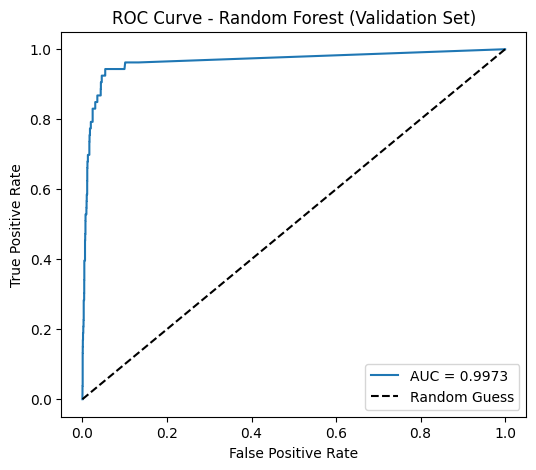

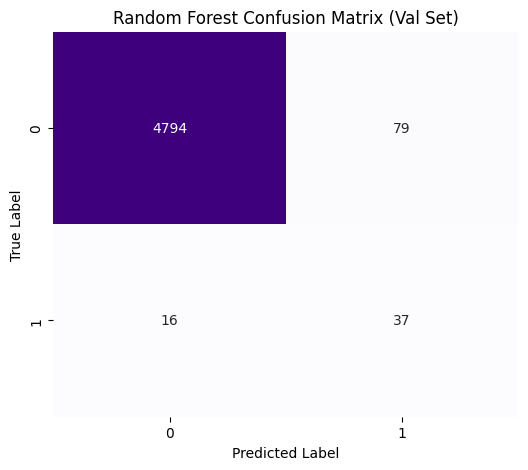

In [273]:
# RF

# Predictions
y_train_pred_rf = grid_search.predict(X_train[features_list])
y_val_pred_rf = grid_search.predict(X_val[features_list])
y_train_prob_rf = grid_search.predict_proba(X_train[features_list])
y_val_prob_rf = grid_search.predict_proba(X_val[features_list])

# Evaluation
auc_roc_train = roc_auc_score(y_train, y_train_prob_rf[:, 1])
auc_roc_val = roc_auc_score(y_val, y_val_prob_rf[:, 1])

# Summary
print(f"Train AUC-ROC: {auc_roc_train:.4f}")
print(f"Validation AUC-ROC: {auc_roc_val:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob_rf[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_roc_train:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Validation Set)')
plt.legend()

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
conf_matrix = confusion_matrix(y_val, y_val_pred_rf)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Random Forest Confusion Matrix (Val Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [1921]:
# Predicting test set
y_test_prob_rf = grid_search.predict_proba(X_test[features_list])
X_test['drafted'] = y_test_prob_rf[:, 1].round(2)

X_test[['player_id', 'drafted']].to_csv('../data/processed/y_test_rf.csv', index=False)

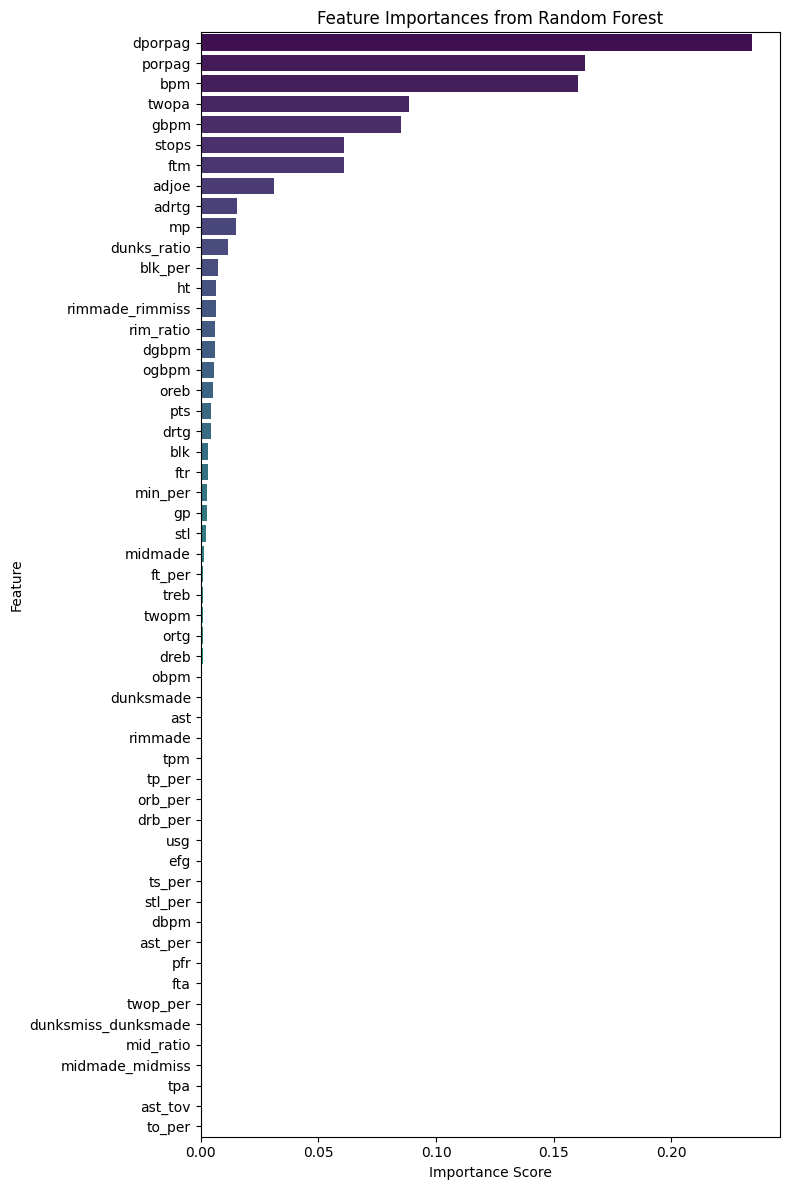

In [1922]:
# Validating feature importance
feature_importances = grid_search.best_estimator_.feature_importances_
importance_df = pd.DataFrame({'Feature': features_list, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8, 12))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [1923]:
# <Student to fill this section>
model_performance_explanations = """
The model selected shows good performance overall, but it correctly predicts drafted players in only 73% of the cases (39 out of 53 as shown in the confusion matrix). The feature importance shows that the majority of features previously shown in the feature selection approach remains with the same importance, but dunks related feature changed importance position.
"""

In [1924]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [1925]:
# <Student to fill this section>
business_impacts_explanations = """
As shown in the confusion matrix from model performance, the current model is performaning well overall but lacking security when it comes to predict drafted players, getting it right only 73% of the cases. With that in mind, the current model is not safe enought to deliver business value since the insight stakeholders most expect is to know potential players to be drafted.
"""

In [1926]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [1927]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [1928]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [1929]:
# <Student to fill this section>
experiment_results_explanations = """
The current random forest model presented failure in predicting drafted players in more than 20% of the cases. Therefore, more experiments must be made in order to achieve better results. In case of desire to proceed with the current model, the feature rec_rank could be an important decision feature, but it needs business knowledge to fix all missing values.
"""

In [1930]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)